This is a notebook in order to do gene set enrichment analysis on the results of an overfitted model. 

Here I define a background set of genes as all the genes for a given cell type and the in_set as the set of genes
for which the model (trained on all genes of a given cell type) misclassified that given gene. Supposedly, these represent
the set of genes for which even an overfitted model can't predict their DEG status (not regulated / atypical regulation 
by the epigenome).

In [5]:
import numpy as np
import pandas as pd

import matplotlib.pyplot as plt
import seaborn as sns

In [6]:
cell_types = ['L23_IT_CTX_Glut','DG_Glut','CA1-ProS_Glut','Oligo_NN','CA3_Glut','L6_CT_CTX_Glut','L6_IT_CTX_Glut','L5_ET_CTX_Glut','Astro-TE_NN','OPC_NN'] #,'Pvalb_Gaba']
_ct = cell_types[0]

In [21]:
for _ct in cell_types: 
    Y_out = pd.read_csv(f"../result_data/xgb_mods/overfit/{_ct}.cv_cs.Y_outs.csv", index_col=0)
    background_set = set(Y_out.index)
    in_set = set(Y_out.loc[Y_out['DEG'] != Y_out['pred']].index)
    print(_ct)
    print(len(background_set), len(in_set), '\n')
    break
    ## TODO Gene Set enrichment analysis

L23_IT_CTX_Glut
9353 2312 



### setup

In [9]:
# !python /gale/netapp/home2/aklein/miniconda3/envs/agp/bin/ncbi_gene_results_to_python.py -o genes_ncbi_mus_proteincoding.py gene_result.txt

In [10]:
from genes_ncbi_mus_proteincoding import GENEID2NT as GeneID2nt_mus

In [11]:
from goatools.base import download_go_basic_obo
from goatools.base import download_ncbi_associations
from goatools.obo_parser import GODag
from goatools.anno.genetogo_reader import Gene2GoReader
from goatools.goea.go_enrichment_ns import GOEnrichmentStudyNS

In [12]:
obo_fname = download_go_basic_obo()
fin_gene2go = download_ncbi_associations()
obodag = GODag(obo_fname)

  EXISTS: go-basic.obo
  EXISTS: gene2go
go-basic.obo: fmt(1.2) rel(2024-10-27) 44,017 Terms


In [13]:
obo_fname, fin_gene2go

('go-basic.obo', 'gene2go')

In [22]:
#run one time to initialize
mapper = {}

for key in GeneID2nt_mus:
    mapper[GeneID2nt_mus[key].Symbol] = GeneID2nt_mus[key].GeneID
    
inv_map = {v: k for k, v in mapper.items()}

In [29]:
# objanno = Gene2GoReader(fin_gene2go, taxids=[10090])
ns2assoc = objanno.get_ns2assc()

In [48]:
# background_set.map

In [57]:
# Mapping in_set and background_set to the gene ids. 
def map_set(gene_set, mapper): 
    mapped_set = []
    for gene in gene_set:
        try:
            mapped_set.append(mapper[gene])
        except:
            pass
    # print(f'mapped genes: {len(mapped_set)}')
    return mapped_set

In [59]:
mapped_background = map_set(background_set, mapper)
mapped_test = map_set(in_set, mapper)

In [60]:
goeaobj = GOEnrichmentStudyNS(
    mapped_background, # list of mouse protein coding genes
    ns2assoc, # geneid / GO associations 
    obodag, # ontologies
    propagate_counts = False, 
    alpha = 0.05, #significance cutoff
    methods = ['fdr_bh'] # multi-test correction
)


Load BP Ontology Enrichment Analysis ...
 92%  7,774 of  8,474 population items found in association

Load CC Ontology Enrichment Analysis ...
 95%  8,036 of  8,474 population items found in association

Load MF Ontology Enrichment Analysis ...
 86%  7,330 of  8,474 population items found in association


In [61]:
#run one time to initialize
GO_items = []

temp = goeaobj.ns2objgoea['BP'].assoc
for item in temp:
    GO_items += temp[item]
    

temp = goeaobj.ns2objgoea['CC'].assoc
for item in temp:
    GO_items += temp[item]
    

temp = goeaobj.ns2objgoea['MF'].assoc
for item in temp:
    GO_items += temp[item]

In [64]:
#pass list of gene symbols
def go_it(test_set):
    print(f'input genes: {len(test_set)}')

    goea_results_all = goeaobj.run_study(test_set)
    goea_results_sig = [r for r in goea_results_all if r.p_fdr_bh < 0.05]
    GO = pd.DataFrame(list(map(lambda x: [x.GO, x.goterm.name, x.goterm.namespace, x.p_uncorrected, x.p_fdr_bh,\
                   x.ratio_in_study[0], x.ratio_in_study[1], GO_items.count(x.GO), list(map(lambda y: inv_map[y], x.study_items)),\
                   ], goea_results_sig)), columns = ['GO', 'term', 'class', 'p', 'p_corr', 'n_genes',\
                                                    'n_study', 'n_go', 'study_genes'])

    GO = GO[GO.n_genes > 1]
    return GO

In [65]:
df = go_it(mapped_test)

input genes: 2150

Runing BP Ontology Analysis: current study set of 2150 IDs.
 93%  1,989 of  2,150 study items found in association
100%  2,150 of  2,150 study items found in population(8474)
Calculating 9,850 uncorrected p-values using fisher_scipy_stats
   9,850 terms are associated with  7,774 of  8,474 population items
   5,504 terms are associated with  1,989 of  2,150 study items
  METHOD fdr_bh:
       0 GO terms found significant (< 0.05=alpha) (  0 enriched +   0 purified): statsmodels fdr_bh
       0 study items associated with significant GO IDs (enriched)
       0 study items associated with significant GO IDs (purified)

Runing CC Ontology Analysis: current study set of 2150 IDs.
 95%  2,052 of  2,150 study items found in association
100%  2,150 of  2,150 study items found in population(8474)
Calculating 1,571 uncorrected p-values using fisher_scipy_stats
   1,571 terms are associated with  8,036 of  8,474 population items
   1,012 terms are associated with  2,052 of  2,

In [66]:
df['per'] = df.n_genes / df.n_go

In [68]:
df

,GO,term,class,p,p_corr,n_genes,n_study,n_go,study_genes,per
0,GO:0030425,dendrite,cellular_component,6.175122e-07,0.000970,154,2150,634,"[Cacna1g, Lrp4, P2rx4, Cobl, Epha5, Calb1, Eph...",0.242902
1,GO:0030424,axon,cellular_component,4.174340e-06,0.002885,118,2150,511,"[Myo6, Llgl1, Ap3d1, Cntn1, P2rx4, Cobl, Smurf...",0.230920
2,GO:0098978,glutamatergic synapse,cellular_component,5.509684e-06,0.002885,196,2150,849,"[Myo6, Ap3d1, Fbxl20, Dapk1, Cntn1, Cacnb4, Ca...",0.230860
3,GO:0014069,postsynaptic density,cellular_component,7.949970e-05,0.031224,88,2150,333,"[Myo6, Dapk1, Lrp4, Abhd17c, Ppp1r9b, Grm3, Ca...",0.264264
4,GO:0005515,protein binding,molecular_function,2.399051e-06,0.008404,822,2150,5577,"[Mybbp1a, Cacna1d, Dapk1, Rnf41, Cacna1g, Cacn...",0.147391


In [81]:
from matplotlib import cm
import matplotlib as mpl
import textwrap

In [76]:
norm = mpl.colors.Normalize(vmin = df.p_corr.min(), vmax = df.p_corr.max())
go_palette = cm.ScalarMappable(norm = norm, cmap=cm.bwr_r)

/gale/ddn/aging/aklein/240903_aging_mice/aging_gene_prediction/aging_gene_prediction/ak_workspace/analyze_results/ipykernel_317/1729738491.py:2: UserWarning: Numpy array is not a supported type for `palette`. Please convert your palette to a list. This will become an error in v0.14
  ax = sns.barplot(data=df, x='per', y = 'term', hue ='term', palette = go_palette.to_rgba(df.p_corr.values))
/gale/ddn/aging/aklein/240903_aging_mice/aging_gene_prediction/aging_gene_prediction/ak_workspace/analyze_results/ipykernel_317/1729738491.py:4: UserWarning: set_ticklabels() should only be used with a fixed number of ticks, i.e. after set_ticks() or using a FixedLocator.
  ax.set_yticklabels([textwrap.fill(e, 22) for e in df['term']])


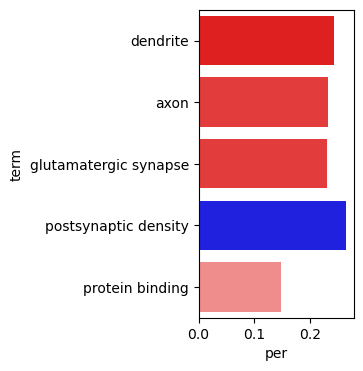

In [84]:
fig, ax = plt.subplots(figsize=(2, 4))
ax = sns.barplot(data=df, x='per', y = 'term', hue ='term', palette = go_palette.to_rgba(df.p_corr.values))

ax.set_yticklabels([textwrap.fill(e, 22) for e in df['term']])

plt.show()

### Functionalize

In [ ]:
# goatools imports
from genes_ncbi_mus_proteincoding import GENEID2NT as GeneID2nt_mus
from goatools.base import download_go_basic_obo
from goatools.base import download_ncbi_associations
from goatools.obo_parser import GODag
from goatools.anno.genetogo_reader import Gene2GoReader
from goatools.goea.go_enrichment_ns import GOEnrichmentStudyNS

# filename loadings
obo_fname = download_go_basic_obo()
fin_gene2go = download_ncbi_associations()
obodag = GODag(obo_fname) # ontologies DAG

# Gene name to ID mapper
mapper = {}

for key in GeneID2nt_mus:
    mapper[GeneID2nt_mus[key].Symbol] = GeneID2nt_mus[key].GeneID
    
inv_map = {v: k for k, v in mapper.items()}

# Associations between gene id and go terms
objanno = Gene2GoReader(fin_gene2go, taxids=[10090])
ns2assoc = objanno.get_ns2assc()

In [ ]:
# Function for mapping gene names to gene ids 
def map_set(gene_set, mapper): 
    mapped_set = []
    for gene in gene_set:
        try:
            mapped_set.append(mapper[gene])
        except:
            pass
    return mapped_set

# Doing the mapping
mapped_background = map_set(background_set, mapper)
mapped_test = map_set(in_set, mapper)

In [ ]:
# The enrichment study object
goeaobj = GOEnrichmentStudyNS(
    mapped_background, # list of mouse protein coding genes
    ns2assoc, # geneid / GO associations 
    obodag, # ontologies
    propagate_counts = False, 
    alpha = 0.05, #significance cutoff
    methods = ['fdr_bh'] # multi-test correction
)

In [ ]:
# Adding all the GO terms for all categories to a shared list
GO_items = []
# BP - Biological Process
temp = goeaobj.ns2objgoea['BP'].assoc
for item in temp:
    GO_items += temp[item]
# CC - Cellular Component
temp = goeaobj.ns2objgoea['CC'].assoc
for item in temp:
    GO_items += temp[item]
# MF - Molecular Function
temp = goeaobj.ns2objgoea['MF'].assoc
for item in temp:
    GO_items += temp[item]

In [109]:
#pass list of gene symbols
def go_it(test_set, alpha=0.05):
    print(f'input genes: {len(test_set)}')

    # Running the test
    goea_results_all = goeaobj.run_study(test_set)
    # Getting only sig. results below alpha
    goea_results_sig = [r for r in goea_results_all if r.p_fdr_bh < alpha]
    # Making it into a dataframe
    GO = pd.DataFrame(list(map(lambda x: [x.GO, x.goterm.name, x.goterm.namespace, x.p_uncorrected, x.p_fdr_bh,\
                   x.ratio_in_study[0], x.ratio_in_study[1], GO_items.count(x.GO), list(map(lambda y: inv_map[y], x.study_items)),\
                   ], goea_results_sig)), columns = ['GO', 'term', 'class', 'p', 'p_corr', 'n_genes',\
                                                    'n_study', 'n_go', 'study_genes'])
    # Double Check no empty categories
    GO = GO[GO.n_genes > 1]
    return GO

In [2]:
from utilities.genes_ncbi_mus_proteincoding import GENEID2NT as GeneID2nt_mus

In [111]:
# goatools imports
from genes_ncbi_mus_proteincoding import GENEID2NT as GeneID2nt_mus
from goatools.base import download_go_basic_obo
from goatools.base import download_ncbi_associations
from goatools.obo_parser import GODag
from goatools.anno.genetogo_reader import Gene2GoReader
from goatools.goea.go_enrichment_ns import GOEnrichmentStudyNS

def GO_analysis(in_set, out_set): 
    # filename loadings
    obo_fname = download_go_basic_obo()
    fin_gene2go = download_ncbi_associations()
    obodag = GODag(obo_fname) # ontologies DAG
    
    # Gene name to ID mapper
    mapper = {}
    
    for key in GeneID2nt_mus:
        mapper[GeneID2nt_mus[key].Symbol] = GeneID2nt_mus[key].GeneID
        
    inv_map = {v: k for k, v in mapper.items()}
    
    # Associations between gene id and go terms
    objanno = Gene2GoReader(fin_gene2go, taxids=[10090])
    ns2assoc = objanno.get_ns2assc()

    # Function for mapping gene names to gene ids 
    def map_set(gene_set, mapper): 
        mapped_set = []
        for gene in gene_set:
            try:
                mapped_set.append(mapper[gene])
            except:
                pass
        return mapped_set
    
    # Doing the mapping
    mapped_background = map_set(background_set, mapper)
    mapped_test = map_set(in_set, mapper)

    # The enrichment study object
    goeaobj = GOEnrichmentStudyNS(
        mapped_background, # list of mouse protein coding genes
        ns2assoc, # geneid / GO associations 
        obodag, # ontologies
        propagate_counts = False, 
        alpha = 0.05, #significance cutoff
        methods = ['fdr_bh'] # multi-test correction
    )

    # Adding all the GO terms for all categories to a shared list
    GO_items = []
    # BP - Biological Process
    temp = goeaobj.ns2objgoea['BP'].assoc
    for item in temp:
        GO_items += temp[item]
    # CC - Cellular Component
    temp = goeaobj.ns2objgoea['CC'].assoc
    for item in temp:
        GO_items += temp[item]
    # MF - Molecular Function
    temp = goeaobj.ns2objgoea['MF'].assoc
    for item in temp:
        GO_items += temp[item]
    
    #pass list of gene symbols
    def go_it(test_set, alpha=0.05):
        print(f'input genes: {len(test_set)}')
    
        # Running the test
        goea_results_all = goeaobj.run_study(test_set)
        # Getting only sig. results below alpha
        goea_results_sig = [r for r in goea_results_all if r.p_fdr_bh < alpha]
        # Making it into a dataframe
        GO = pd.DataFrame(list(map(lambda x: [x.GO, x.goterm.name, x.goterm.namespace, x.p_uncorrected, x.p_fdr_bh,\
                       x.ratio_in_study[0], x.ratio_in_study[1], GO_items.count(x.GO), list(map(lambda y: inv_map[y], x.study_items)),\
                       ], goea_results_sig)), columns = ['GO', 'term', 'class', 'p', 'p_corr', 'n_genes',\
                                                        'n_study', 'n_go', 'study_genes'])
        # Double Check no empty categories
        GO = GO[GO.n_genes > 1]
        return GO
    df_res = go_it(mapped_test)
    return df_res

In [112]:
GO_analysis(in_set, background_set)

  EXISTS: go-basic.obo
  EXISTS: gene2go
go-basic.obo: fmt(1.2) rel(2024-10-27) 44,017 Terms
HMS:0:01:28.668716 493,645 annotations, 29,826 genes, 19,233 GOs, 1 taxids READ: gene2go 

Load BP Ontology Enrichment Analysis ...
 92%  7,774 of  8,474 population items found in association

Load CC Ontology Enrichment Analysis ...
 95%  8,036 of  8,474 population items found in association

Load MF Ontology Enrichment Analysis ...
 86%  7,330 of  8,474 population items found in association
input genes: 2150

Runing BP Ontology Analysis: current study set of 2150 IDs.
 93%  1,989 of  2,150 study items found in association
100%  2,150 of  2,150 study items found in population(8474)
Calculating 9,850 uncorrected p-values using fisher_scipy_stats
   9,850 terms are associated with  7,774 of  8,474 population items
   5,504 terms are associated with  1,989 of  2,150 study items
  METHOD fdr_bh:
       0 GO terms found significant (< 0.05=alpha) (  0 enriched +   0 purified): statsmodels fdr_bh
  

,GO,term,class,p,p_corr,n_genes,n_study,n_go,study_genes
0,GO:0030425,dendrite,cellular_component,6.175122e-07,0.000970,154,2150,634,"[Cacna1g, Lrp4, P2rx4, Cobl, Epha5, Calb1, Eph..."
1,GO:0030424,axon,cellular_component,4.174340e-06,0.002885,118,2150,511,"[Myo6, Llgl1, Ap3d1, Cntn1, P2rx4, Cobl, Smurf..."
2,GO:0098978,glutamatergic synapse,cellular_component,5.509684e-06,0.002885,196,2150,849,"[Myo6, Ap3d1, Fbxl20, Dapk1, Cntn1, Cacnb4, Ca..."
3,GO:0014069,postsynaptic density,cellular_component,7.949970e-05,0.031224,88,2150,333,"[Myo6, Dapk1, Lrp4, Abhd17c, Ppp1r9b, Grm3, Ca..."
4,GO:0005515,protein binding,molecular_function,2.399051e-06,0.008404,822,2150,5577,"[Mybbp1a, Cacna1d, Dapk1, Rnf41, Cacna1g, Cacn..."
